<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_3_GPT_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openai

# **Classification on Social Cognitive Dimension**

Figure 5.1: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the social-cognitive dimension for the implemented models.

## gpt-4o-2024-08-06; using fine-tuned model ft:gpt-4o-2024-08-06:personal::C0saJ5za

In [ ]:
%reset -f
import pandas as pd
from openai import OpenAI
from tqdm import tqdm

# ==== CONFIGURATION ====
API_KEY = "..."
MODEL_NAME = "ft:gpt-4o-2024-08-06:personal::C0saJ5za"
INPUT_FILE = '/.../test_df_cognitive.xlsx'
OUTPUT_FILE = "/.../4o_cognitive_test_with_labels.xlsx"

client = OpenAI(api_key=API_KEY)

df = pd.read_excel(INPUT_FILE)

codebook_df = pd.read_excel("/.../SocialCognitive_Codebook_fordataset.xlsx")
codebook_text = "\n\n".join(
    f"Subskill Label: {row['Subskill Label']}\nSubskill: {row['Subskill']}\nIndicator: {row['Indicator']}\nDefinition: {row['Definition']}"
    for _, row in codebook_df.iterrows()
)

system_prompt = f"""
You are a coding assistant specializing in assigning the correct *Subskill Label* by analysing the *Utterance*.
Instruction: Use the following codebook to analyze utterances.
For each *Utterance*, identify which *Definition* it fits best to obtain the corresponding *Indicator*, *Subskill*, and *Subskill Label*.

Provide only the *Subskill Label* for that *Utterance*.
If unsure, return the *Subskill Label* that you determine is most suitable.
The *Subskill Label* can only be one of the following: SS1, SS2, SS3, SS4, SS5, SS6, SS7, SS8, SC1, SC2

CODEBOOK:
{codebook_text}

"""
print(system_prompt)

def get_label(utterance):
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": utterance}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()

df.to_excel(OUTPUT_FILE, index=False)
print(f"Predictions saved to {OUTPUT_FILE}")

Classification Report:
               precision    recall  f1-score   support

         SS1      0.081     0.791     0.147        43
         SS2      0.376     0.229     0.284       245
         SS3      0.270     0.243     0.256        70
         SS4      0.263     0.833     0.400         6
         SS5      0.102     0.263     0.147        19
         SS6      0.059     0.080     0.068        25
         SS7      0.000     0.000     0.000         4
         SS8      0.059     0.100     0.074        10
         SC1      0.588     0.179     0.275       318
         SC2      0.593     0.203     0.303       172

   micro avg      0.232     0.232     0.232       912
   macro avg      0.239     0.292     0.195       912
weighted avg      0.448     0.232     0.264       912
 samples avg      0.232     0.232     0.232       912

Accuracy: 0.232
Precision: 0.448
Recall: 0.232
F1 Score: 0.264



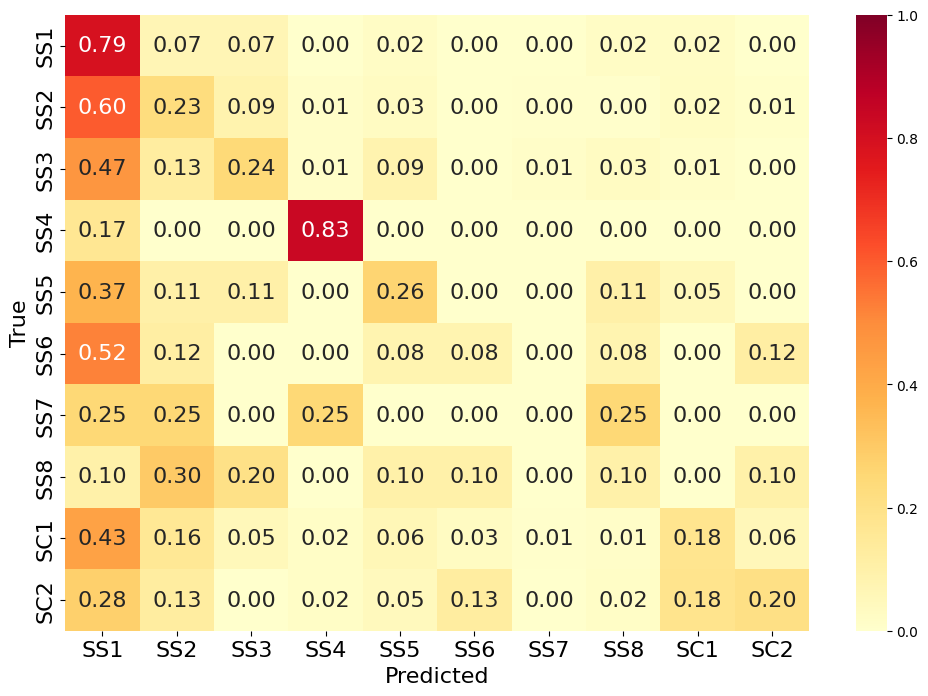

In [ ]:
%reset -f
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

file = "/.../4o_cognitive_test_with_labels.xlsx"

df = pd.read_excel(file)

true_vals = df["True_Label"].values  # True labels from df
predictions = df["Predicted_Label"].values  # Predicted labels from df

label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

true_vals = df["True_Label"].map(label_dict).values
predictions = df["Predicted_Label"].map(label_dict).values

y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

# **Classification on Affective Dimension**

Figure 5.2: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the affective dimension for the implemented models.

## gpt-4o-2024-08-06

In [ ]:
%reset -f
import pandas as pd
from openai import OpenAI

API_KEY = "..."
MODEL_NAME = "gpt-4o-2024-08-06"
INPUT_FILE = '/.../test_df_affective.xlsx'
OUTPUT_FILE = "/.../4o_affective_test_with_labels.xlsx"

client = OpenAI(api_key=API_KEY)

df = pd.read_excel(INPUT_FILE)


codebook_df = pd.read_excel("/.../Affective_Codebook_fordataset.xlsx")
codebook_text = "\n\n".join(
    f"Affect Label: {row['Affect Label']}\nAffect: {row['Affect']}\nIndicator: {row['Indicator']}\nDefinition: {row['Definition']}"
    for _, row in codebook_df.iterrows()
)

system_prompt = f"""
You are a coding assistant specializing in assigning the correct *Affect Label* by analysing the *Utterance*.
Instruction: Use the following codebook to analyze utterances.
For each *Utterance*, identify which *Definition* it fits best to obtain the corresponding *Indicator*, *Affect*, and *Affect Label*.

Provide only the *Affect Label* for that *Utterance*.
If unsure, return the *Affect Label* that you determine is most suitable.
The *Affect Label* can only be one of the following: AS1, AS2, AS3

CODEBOOK:
{codebook_text}

"""
print(system_prompt)
tqdm.pandas()

def get_label(utterance):
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": utterance}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()

df.to_excel(OUTPUT_FILE, index=False)
print(f"Predictions saved to {OUTPUT_FILE}")

Classification Report:
               precision    recall  f1-score   support

         AS1      0.745     0.947     0.834       114
         AS2      0.961     0.804     0.876       184
         AS3      0.857     0.750     0.800         8

   micro avg      0.856     0.856     0.856       306
   macro avg      0.854     0.834     0.837       306
weighted avg      0.878     0.856     0.858       306
 samples avg      0.856     0.856     0.856       306

Accuracy: 0.856
Precision: 0.878
Recall: 0.856
F1 Score: 0.858



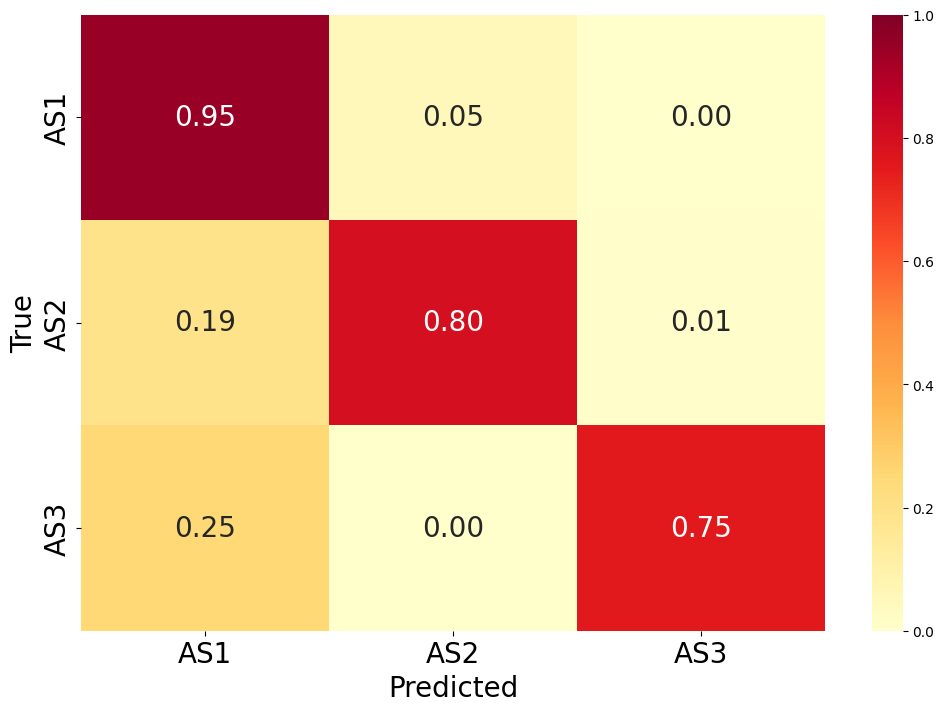

In [ ]:
%reset -f
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

file = "/.../4o_affective_test_with_labels.xlsx"

df = pd.read_excel(file)

true_vals = df["True_Label"].values
predictions = df["Predicted_Label"].values

label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

true_vals = df["True_Label"].map(label_dict).values
predictions = df["Predicted_Label"].map(label_dict).values

y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()